# ⛰️ Lecture 13 – Data 100

Data 100, Fall 2026

[Acknowledgments Page](https://ds100.org/acknowledgements)

In [1]:
import polars as pl
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np

# Set display options for numpy
np.set_printoptions(suppress=True, precision=6)

<br/><br/>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />

## Fiting our Multiple Linear Regression Model

Consider the `penguins` dataset.

In [2]:
# Load in the penguins dataset provided by seaborn package
df = pl.from_pandas(sns.load_dataset("penguins"))

# Filter to only include Adelie species and remove any rows with missing values.
# Remember that dropping rows with missing values should be done CAREFULLY.
# Here, we drop rows just so the demo modeling code runs without error.
df = df.filter(pl.col("species") == "Adelie").drop_nulls()

df

species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
str,str,f64,f64,f64,f64,str
"""Adelie""","""Torgersen""",39.1,18.7,181.0,3750.0,"""Male"""
"""Adelie""","""Torgersen""",39.5,17.4,186.0,3800.0,"""Female"""
"""Adelie""","""Torgersen""",40.3,18.0,195.0,3250.0,"""Female"""
"""Adelie""","""Torgersen""",36.7,19.3,193.0,3450.0,"""Female"""
"""Adelie""","""Torgersen""",39.3,20.6,190.0,3650.0,"""Male"""
…,…,…,…,…,…,…
"""Adelie""","""Dream""",36.6,18.4,184.0,3475.0,"""Female"""
"""Adelie""","""Dream""",36.0,17.8,195.0,3450.0,"""Female"""
"""Adelie""","""Dream""",37.8,18.1,193.0,3750.0,"""Male"""


Suppose we could measure flippers and weight easily, but not bill dimensions.
How can we predict **bill depth** from flipper length and/or body mass?

For demo purposes, we'll drop all columns except the variables whose relationships we're interested in modeling.

In [3]:
df = df.select("bill_depth_mm", "flipper_length_mm", "body_mass_g")
df

bill_depth_mm,flipper_length_mm,body_mass_g
f64,f64,f64
18.7,181.0,3750.0
17.4,186.0,3800.0
18.0,195.0,3250.0
19.3,193.0,3450.0
20.6,190.0,3650.0
…,…,…
18.4,184.0,3475.0
17.8,195.0,3450.0
18.1,193.0,3750.0


Suppose we want to create a linear regression model that predicts a penguin's **bill depth** $y$ using both their **flipper length** $x_1$ and **body mass** $x_2$, plus an intercept term.

$$\Large \hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2$$

Another way to write this:

$$ \widehat{\texttt{bill\_depth\_mm}} = \theta_0 + \theta_1 * \texttt{flipper\_length\_mm} + \theta_2 * \texttt{body\_mass\_g} $$

### OLS Approach 1: Use Solution to Normal Equation

We saw in last lecture that we can model the above multiple linear regression equation using matrix multiplication:

$$ \large \hat{\mathbb{Y}} = \mathbb{X} \theta$$

The optimal $\hat{\theta}$ that minimizes MSE also solves the **normal equation**:

$$ \left( \mathbb{X}^T \mathbb{X} \right) \hat{\theta} = \mathbb{X}^T \mathbb{Y}$$

If $\mathbb{X}$ is full column rank, then there is a unique solution to $\hat{\theta}$:

$$\large \hat{\theta} = \left( \mathbb{X}^T \mathbb{X} \right)^{-1} \mathbb{X}^T \mathbb{Y}$$

> Note: This derivation is one of the most challenging in the course, especially for those of you who are learning linear algebra during the same semester. Be kind to yourself!

<br/>

---

Let's try this in code. We have to add a bias column to the design matrix if we want to include an intercept in the model:

In [4]:
# Construct the design matrix X as a dataframe and add a bias column
X = df.select("flipper_length_mm", "body_mass_g")

# Notice how using 1 (or pl.lit(1)) broadcasts a single value to all rows.
X = X.with_columns(bias=1)

# Let's put the bias column in front.
X = X.select("bias", "flipper_length_mm", "body_mass_g")

X

bias,flipper_length_mm,body_mass_g
i32,f64,f64
1,181.0,3750.0
1,186.0,3800.0
1,195.0,3250.0
1,193.0,3450.0
1,190.0,3650.0
…,…,…
1,184.0,3475.0
1,195.0,3450.0
1,193.0,3750.0


In [5]:
# Construct the outcome vector y
y = df["bill_depth_mm"]
y

bill_depth_mm
f64
18.7
17.4
18.0
19.3
20.6
…
18.4
17.8
18.1


Recall the solution to the normal equation if $\mathbb{X}$ is full column rank:

$$\hat{\theta} = \left( \mathbb{X}^T \mathbb{X} \right)^{-1} \mathbb{X}^T \mathbb{Y}$$

In [6]:
# .to_numpy() hands the dataframe and the outcome vector to NumPy as matrices
# M.T transposes a matrix M
# X @ Y multiplies matrices X and Y
# np.linalg.inv(M) finds the inverse of a matrix M
X_mat, y_vec = X.to_numpy(), y.to_numpy()
theta_using_normal_equation = np.linalg.inv(X_mat.T @ X_mat) @ X_mat.T @ y_vec
theta_using_normal_equation

array([11.002995,  0.009828,  0.001477])

So, our fitted model is as follows:

$$ \widehat{\texttt{bill\_depth\_mm}} = 11 + 0.0098 * \texttt{flipper\_length\_mm} + 0.0015 * \texttt{body\_mass\_g} $$

Note: The code above is inefficient. We won't go into this in Data 100, but it's better to use `np.linalg.solve` rather than computing the explicit matrix inverse:

In [7]:
# Solves for θ in (XTX)θ = XTy (i.e., the normal equation) using a system of linear equations
np.linalg.solve(X_mat.T @ X_mat, X_mat.T @ y_vec)

array([11.002995,  0.009828,  0.001477])

#### Make Predictions
We'll save the predictions in a column so we can compare them against predictions from `sklearn` in the next section.

In [8]:
# Convert the dataframe representation of the design matrix to a numpy array, 
# and then multiply it by the theta vector to get the predicted outcomes.
# Yhat = Xθ
df = df.with_columns(
    pred_bill_depth_mm=pl.Series(X.to_numpy() @ theta_using_normal_equation)
)
df

bill_depth_mm,flipper_length_mm,body_mass_g,pred_bill_depth_mm
f64,f64,f64,f64
18.7,181.0,3750.0,18.322561
17.4,186.0,3800.0,18.445578
18.0,195.0,3250.0,17.721412
19.3,193.0,3450.0,17.997254
20.6,190.0,3650.0,18.263268
…,…,…,…
18.4,184.0,3475.0,17.945735
17.8,195.0,3450.0,18.016911
18.1,193.0,3750.0,18.440503


<br><br><br>

**Instructor Note: Return to Lecture!**

<br><br>

<br/><br/>

### Using `sklearn` to fit our Multiple Linear Regression Model

An alternate approach to optimize our model is to use the `sklearn.linear_model.LinearRegression` class. [(Documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [9]:
# Import the LinearRegression class
from sklearn.linear_model import LinearRegression

1. **Create an `sklearn` object.**

    First we create a model. At this point the model has not been fit so it has no parameters.

In [10]:
# Construct a blank LinearRegression model object
model = LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


2. **`fit` the object to data.**

Then we "fit" the model, which means computing the parameters that minimize the loss function. 
    
The first argument of the fit function should be a matrix (or DataFrame), and the second should be the observations we're trying to predict. 

Note: The `LinearRegression` class is hard-coded to use the **MSE** as its loss function.

3. **Analyze fit or call `predict`.**

    Now that our model is trained, we can ask it questions.

In [11]:
# Fit the linear regression model to the data
model.fit(
    X=df.select("flipper_length_mm", "body_mass_g"),
    y=df["bill_depth_mm"]
  )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.01,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['flipper_length_mm','body_mass_g']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [11]:
model.fit(
    X=df.select("flipper_length_mm", "body_mass_g"),
    y=df["bill_depth_mm"]
)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.01,0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['flipper_length_mm','body_mass_g']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


The code below asks the model to estimate the bill depth (in mm) for three different penguins with different flipper lengths and body masses.

In [ ]:
model.predict(df.select("flipper_length_mm", "body_mass_g"))

In [12]:
# Suppose we collected data from three new penguins:
new_penguins = pl.DataFrame({
    'flipper_length_mm': [185, 175, 145],
    'body_mass_g': [3750.0, 3550.0, 3250.0],
})
# Generate a prediction (yhat) by providing the X values to the model.

model.predict(new_penguins)

array([18.361875, 17.968091, 17.229988])

Let's save the scikit-learn model predictions as a column in our dataframe:

In [13]:
# Can also provide a design matrix or dataframe to .predict()
df = df.with_columns(
    sklearn_preds=pl.Series(model.predict(df[["flipper_length_mm", "body_mass_g"]]))
)
df

bill_depth_mm,flipper_length_mm,body_mass_g,pred_bill_depth_mm,sklearn_preds
f64,f64,f64,f64,f64
18.7,181.0,3750.0,18.322561,18.322561
17.4,186.0,3800.0,18.445578,18.445578
18.0,195.0,3250.0,17.721412,17.721412
19.3,193.0,3450.0,17.997254,17.997254
20.6,190.0,3650.0,18.263268,18.263268
…,…,…,…,…
18.4,184.0,3475.0,17.945735,17.945735
17.8,195.0,3450.0,18.016911,18.016911
18.1,193.0,3750.0,18.440503,18.440503


Looking at the predictions above, we see that they are exactly the same as what we calculated with our analytic formula!

**Analyze parameters.**

We can ask the model for its intercept and slope with `_intercept` and `_coef`, respectively.

In [14]:
# There is one intercept term in the model
model.intercept_

np.float64(11.002995277447068)

In [15]:
# There are two slope terms in the model
model.coef_

array([0.009828, 0.001477])

So, our fitted model is as follows:

$$ \widehat{\texttt{bill\_depth\_mm}} = 11 + 0.0098 * \texttt{flipper\_length\_mm} + 0.0015 * \texttt{body\_mass\_g} $$

The parameters are the same as with our analytic formula.

In [16]:
# vs. analytical solutions
theta_using_normal_equation

array([11.002995,  0.009828,  0.001477])

They look the same!

### Visualize the Fit
We can visualize this data in three dimensions, but for many (most) real-world problems this will not be possible (or helpful).

Note: the following code is out of scope for this class. *Exercise: when is this kind of visualization useful? What kind of search terms or LLM prompt might you use to create something like this on your own?*

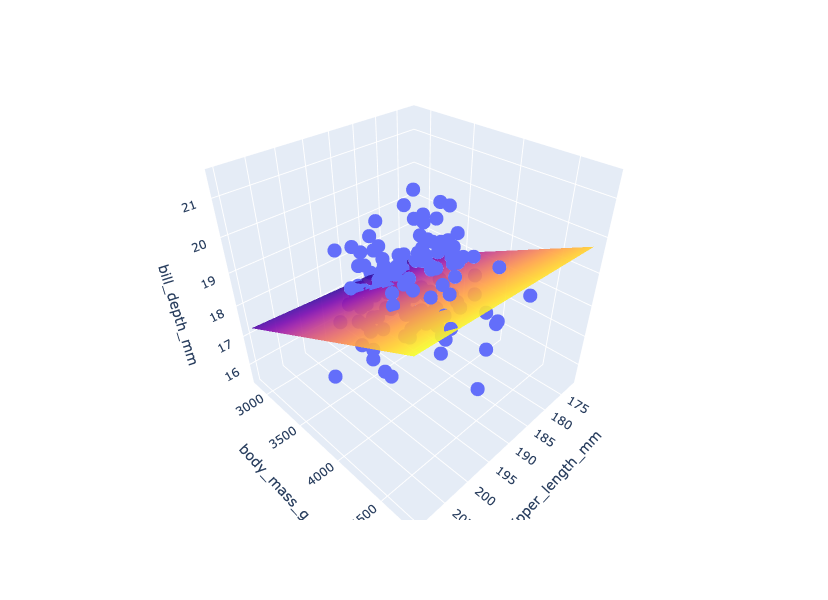

In [17]:
fig = px.scatter_3d(df, x="flipper_length_mm", y="body_mass_g", z="bill_depth_mm")

# Create a grid of points to evaluate plane
grid_resolution = 2
(u,v) = np.meshgrid(
    np.linspace(df["flipper_length_mm"].min(), df["flipper_length_mm"].max(), grid_resolution),
    np.linspace(df["body_mass_g"].min(), df["body_mass_g"].max(), grid_resolution))
features = pl.DataFrame({"flipper_length_mm": u.flatten(),
                         "body_mass_g": v.flatten()})
# Make predictions at every point on the grid
zs = model.predict(features)

# create the Surface
fig.add_trace(go.Surface(x=u, y=v, z= zs.reshape(u.shape), opacity=0.9, showscale=False))
fig.update_layout(autosize=False, width=800, height=600)

We see that the predictions all lie in a plane. In higher dimensions, the predictions all lie in a "hyperplane".

### Analyze performance.

The `sklearn` package also provides a function `mean_squared_error()` ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html)) that computes the MSE from a list of observations and predictions. This avoids us having to manually compute MSE by first computing residuals.

In [18]:
# Calculate the MSE for a prediction vector and a ground truth outcome vector
from sklearn.metrics import mean_squared_error

mean_squared_error(df["bill_depth_mm"], df["sklearn_preds"])

0.9764070438844

<br><br>

**Instructor Note: Return to Lecture!**

<br><br>
<hr style="border: 5px solid #003262;" />
<hr style="border: 1px solid #fdb515;" />


## Gradient Descent: Minimizing an Arbitrary 1D Function

Suppose we want to find the value of $x$ that minimizes the arbitrary function given below:

$$
\frac{1}{10}\left(x^4 - 15x^3 + 80 x^2 - 180x + 144\right)
$$

In [19]:
def f(x):
    return (x**4 - 15*x**3 + 80*x**2 - 180*x + 144)/10

Minimization via visualization:

In [20]:
x = np.linspace(1, 6.75, 200)
fig = px.line(y = f(x), x = x)
fig.update_layout(font_size = 16)
fig.update_layout(autosize=False, width=800, height=600)

Above, we see that the minimum is somewhere around 5.3ish.

### The Naive Approach: Guess and Check

Another approach would be to guess and check

In [21]:
# np.argmin returns the index of the smallest value in an array
# This function returns the x value corresponding to the smallest
# value of f(x), for an input array of x values
def simple_minimize(f, xs):
    y = [f(x) for x in xs]
    return xs[np.argmin(y)]

In [22]:
guesses = [5.3, 5.31, 5.32, 5.33, 5.34, 5.35]
simple_minimize(f, guesses)

5.33

This process is essentially the same as before where we made a graphical plot, it's just that we're only looking at a few selected points.

In [23]:
xs = np.linspace(1, 7, 200)
sparse_xs = np.linspace(1.5, 6.5, 5)

ys = f(xs)
sparse_ys = f(sparse_xs)

fig = px.line(x = xs, y = f(xs))
fig.add_scatter(x = sparse_xs, y = f(sparse_xs), mode = "markers", marker_size=16)
fig.update_layout(showlegend= False)
fig.update_layout(autosize=False, width=800, height=600)
fig.show()

This basic approach suffers from three major flaws:
1. If the minimum is outside our range of guesses, the answer will be completely wrong.
2. Even if our range of guesses is correct, if the guesses are too coarse, our answer will be inaccurate.
3. It is not computationally efficient, considering potentially vast numbers of bad guesses

<br/><br/><br/>


### `scipy.optimize.minimize`

One way to minimize this mathematical function is to use the `scipy.optimize.minimize` function. It takes a function and a starting guess and tries to find the minimum.

In [24]:
from scipy.optimize import minimize

# x0 is a starting guess for the value of x that minimizes f.
# minimize() will iteratively try to improve this guess.
# Don't worry about all of the details of the output.
# The important part is "x", the value of x that minimizes f.
minimize(f, x0 = 4)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: -0.6914096788749589
        x: [ 5.326e+00]
      nit: 5
      jac: [-3.055e-06]
 hess_inv: [[ 4.745e-01]]
     nfev: 18
     njev: 9

How can this one line of code find the minimum of any mathematical function so quickly? 

Behind the scenes, `scipy.optimize.minimize` uses a collection of techniques to compute the minimizing value of a function. Many of these techniques operate on numerical approximations to the gradient.

In the next lecture, we will learn the basics of gradient descent, then implement it ourselves.

<br><br><br>

**Instructor Note: Return to Lecture!**